# Lesson 2B: Hierarchical Clustering Practical Applications

## Introduction

You understand hierarchical clustering theory. Now apply it to real data and discover when dendrograms reveal structure that K-Means misses.

Key questions:
- How do you cut a dendrogram to get K clusters?
- When is hierarchical better than K-Means?
- How do dendrograms differ across linkage methods on real data?
- What's the scalability trade-off?

In this lesson:
1. Master cutting dendrograms programmatically
2. Apply to real datasets (iris, customer data)
3. Compare hierarchical vs. K-Means results
4. Evaluate with silhouette and Davies-Bouldin
5. Understand pros/cons trade-offs

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Cutting Dendrograms](#cutting)
4. [Case Study: Iris Clustering](#iris)
5. [Hierarchical vs. K-Means](#comparison)
6. [Real Data: Customer Segmentation](#customers)
7. [Scalability and Performance](#scalability)
8. [Advantages and Disadvantages](#pros-cons)
9. [When to Use Hierarchical](#when)
10. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import time

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


<a name="cutting"></a>
## Cutting Dendrograms: From Tree to K Clusters

### The Concept

A dendrogram is a complete clustering history. To get K clusters, "cut" the tree at a height where you have exactly K clusters.

**Two ways to specify the cut:**
1. `t=K` (maxclust): Cut to create exactly K clusters
2. `t=height` (distance): Cut at a specific merge distance

Cutting for K=3: 3 clusters
Cutting at distance=15: 4 clusters


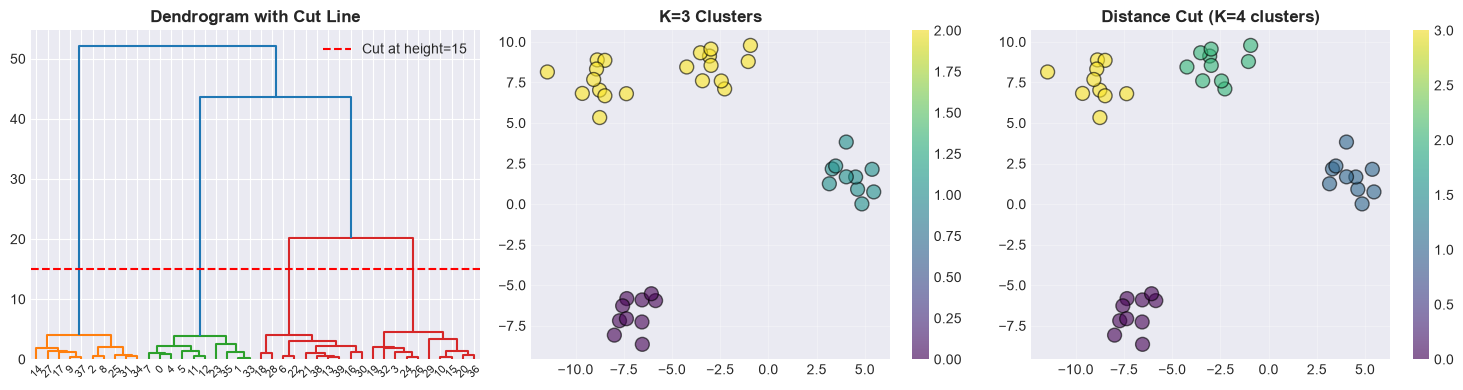

In [2]:
from sklearn.datasets import make_blobs

# Generate sample data
X, y_true = make_blobs(n_samples=40, centers=4, n_features=2, random_state=42)

# Compute linkage
Z = linkage(X, method='ward')

# Method 1: Cut for K=3 clusters
labels_k3 = fcluster(Z, t=3, criterion='maxclust') - 1

# Method 2: Cut at distance threshold
labels_dist = fcluster(Z, t=15, criterion='distance') - 1

print(f"Cutting for K=3: {len(np.unique(labels_k3))} clusters")
print(f"Cutting at distance=15: {len(np.unique(labels_dist))} clusters")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dendrogram with cut lines
ax = axes[0]
dendrogram(Z, ax=ax)
ax.axhline(y=15, color='red', linestyle='--', label='Cut at height=15')
ax.set_title('Dendrogram with Cut Line', fontsize=12, fontweight='bold')
ax.legend()

# Clusters from K=3 cut
ax = axes[1]
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels_k3, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
ax.set_title('K=3 Clusters', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

# Clusters from distance cut
ax = axes[2]
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels_dist, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
ax.set_title(f'Distance Cut (K={len(np.unique(labels_dist))} clusters)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

<a name="iris"></a>
## Case Study: Iris Clustering

In [3]:
# Load and preprocess
iris = load_iris()
X_iris = iris.data
X_iris = StandardScaler().fit_transform(X_iris)

# Apply hierarchical clustering
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hier = agg.fit_predict(X_iris)

# Evaluate
sil_hier = silhouette_score(X_iris, labels_hier)
db_hier = davies_bouldin_score(X_iris, labels_hier)

print(f"Hierarchical (K=3):")
print(f"  Silhouette: {sil_hier:.3f}")
print(f"  Davies-Bouldin: {db_hier:.3f}")
print(f"\nCluster sizes: {np.bincount(labels_hier)}")

Hierarchical (K=3):
  Silhouette: 0.447
  Davies-Bouldin: 0.803

Cluster sizes: [71 49 30]


<a name="comparison"></a>
## Hierarchical vs. K-Means Comparison

K-Means (K=3):
  Silhouette: 0.460
  Davies-Bouldin: 0.834
  Calinski-Harabasz: 241.9

             Method  Silhouette  Davies-Bouldin
Hierarchical (Ward)    0.446689        0.803467
            K-Means    0.459948        0.833595


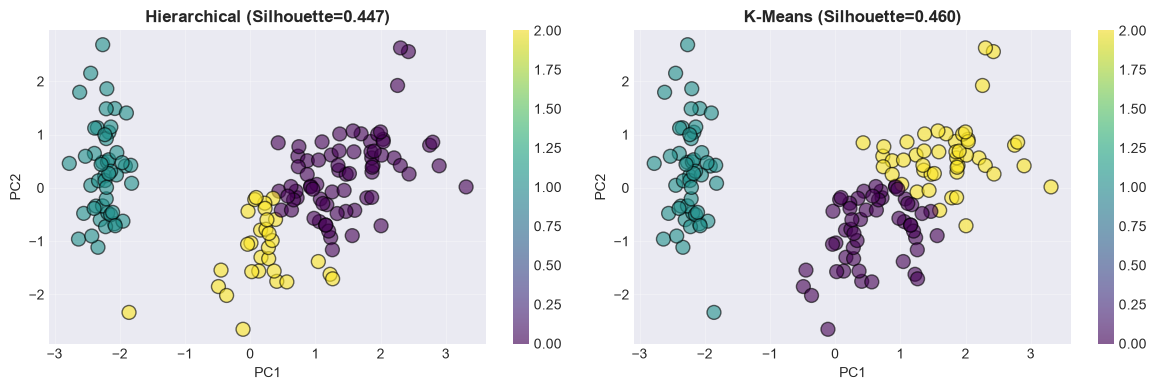


💡 Both methods find similar structure on Iris


In [4]:
# K-Means on same data
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_iris)

sil_km = silhouette_score(X_iris, labels_km)
db_km = davies_bouldin_score(X_iris, labels_km)
ch_km = calinski_harabasz_score(X_iris, labels_km)

print(f"K-Means (K=3):")
print(f"  Silhouette: {sil_km:.3f}")
print(f"  Davies-Bouldin: {db_km:.3f}")
print(f"  Calinski-Harabasz: {ch_km:.1f}")

# Compare
comparison = pd.DataFrame({
    'Method': ['Hierarchical (Ward)', 'K-Means'],
    'Silhouette': [sil_hier, sil_km],
    'Davies-Bouldin': [db_hier, db_km],
})

print(f"\n{comparison.to_string(index=False)}")

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hier, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
ax.set_title(f'Hierarchical (Silhouette={sil_hier:.3f})', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
ax.set_title(f'K-Means (Silhouette={sil_km:.3f})', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

print(f"\n💡 Both methods find similar structure on Iris")

<a name="scalability"></a>
## Scalability and Performance

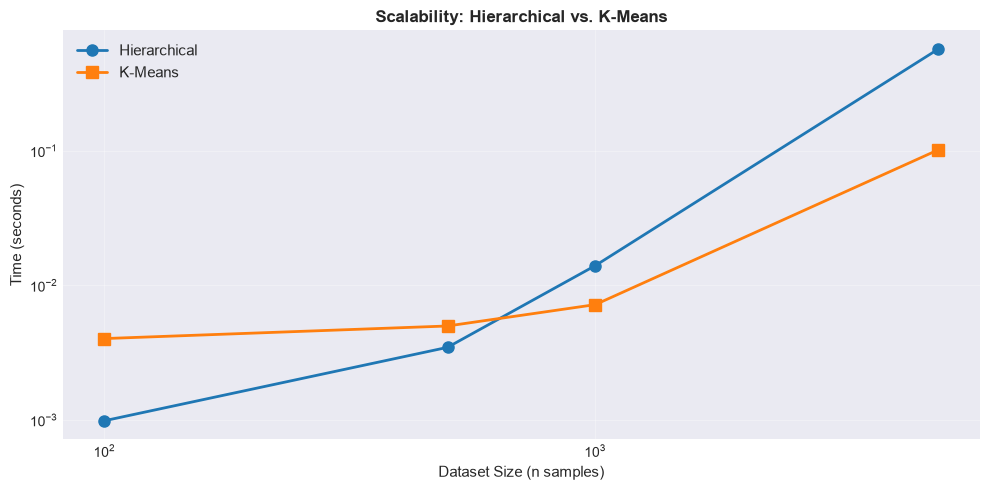

Timing comparison:
  n=  100: Hierarchical=0.001s, K-Means=0.004s, Ratio=0.2x
  n=  500: Hierarchical=0.003s, K-Means=0.005s, Ratio=0.7x
  n= 1000: Hierarchical=0.014s, K-Means=0.007s, Ratio=1.9x
  n= 5000: Hierarchical=0.570s, K-Means=0.102s, Ratio=5.6x

⚠️  Hierarchical is O(n²) — much slower for large datasets


In [5]:
# Benchmark different dataset sizes
sizes = [100, 500, 1000, 5000]
times_hier = []
times_km = []

for size in sizes:
    X, _ = make_blobs(n_samples=size, centers=5, n_features=10, random_state=42)
    
    # Hierarchical
    start = time.time()
    AgglomerativeClustering(n_clusters=5).fit(X)
    times_hier.append(time.time() - start)
    
    # K-Means
    start = time.time()
    KMeans(n_clusters=5, n_init=5, random_state=42).fit(X)
    times_km.append(time.time() - start)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sizes, times_hier, 'o-', linewidth=2, markersize=8, label='Hierarchical')
ax.plot(sizes, times_km, 's-', linewidth=2, markersize=8, label='K-Means')

ax.set_xlabel('Dataset Size (n samples)', fontsize=11)
ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Scalability: Hierarchical vs. K-Means', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Timing comparison:")
for size, t_h, t_km in zip(sizes, times_hier, times_km):
    print(f"  n={size:5d}: Hierarchical={t_h:.3f}s, K-Means={t_km:.3f}s, Ratio={t_h/t_km:.1f}x")

print("\n⚠️  Hierarchical is O(n²) — much slower for large datasets")

<a name="pros-cons"></a>
## Hierarchical Clustering: Pros and Cons

### ✅ Advantages

1. **No K required upfront** — dendrograms reveal structure at all scales
2. **Interpretable trees** — shows how clusters relate to each other
3. **Reveals nesting** — natural hierarchies (e.g., phyla → families → species)
4. **Handles arbitrary shapes** — unlike K-Means (spherical assumption)
5. **Visual insight** — dendrograms are intuitive

### ⚠️ Disadvantages

1. **Computationally expensive** — O(n² log n) or O(n²) time
2. **Memory intensive** — stores full linkage matrix
3. **Greedy algorithm** — merges are never undone (no global optimization)
4. **Sensitive to linkage** — different methods give very different results
5. **Chaining problem** — especially with single linkage
6. **Not scalable** — practical limit ~10,000 samples

### When to Use Each

| Scenario | Method | Why |
|----------|--------|-----|
| Large dataset (n > 10k) | K-Means | Speed |
| Need K upfront | K-Means | Requirement |
| Spherical clusters | K-Means | Optimal |
| Small-medium data (n < 5k) | Hierarchical | Interpretability |
| Unknown cluster structure | Hierarchical | Dendrogram reveals |
| Nested hierarchies (phylogenetics, taxonomy) | Hierarchical | Natural fit |
| Non-convex clusters | DBSCAN | Better for this |


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Cut dendrograms** at appropriate heights using `fcluster(Z, t=K, criterion='maxclust')`

2. **Hierarchical is better than K-Means for**:
   - Understanding cluster relationships
   - Exploring unknown structure
   - Data with natural hierarchies
   - Interpretability requirements

3. **K-Means is better than Hierarchical for**:
   - Large datasets (speed)
   - Fixed K requirements
   - Scalability
   - Spherical, balanced clusters

4. **Linkage choice matters heavily** — ward is most similar to K-Means

5. **Real-world practice**: Often try both and compare via metrics

### Next Lessons

- **DBSCAN (Lesson 3)**: For arbitrary shapes and noise detection
- **Gaussian Mixture Models (Lesson 4)**: Soft, probabilistic clustering
- **Advanced topics**: Spectral clustering, dimensionality reduction + clustering

You've now mastered three major clustering paradigms: **partitioning** (K-Means), **hierarchical** (dendrograms), and next: **density-based** (DBSCAN). This is the foundation of practical unsupervised learning. 🎓